> **Branch:** `feature/stage3-preprocessing`  
> **Author:** Jia  
> ⚠️ **Before running:** Make sure you have already run `stage00_dataset_generator.ipynb` in the same Colab session so that `/content/dataset` and all shared variables are available.


---
# STAGE 3 — Data Preprocessing & Cleaning
**Author: Jia**  
**Branch: feature/stage3-preprocessing**

---

### Steps:
1. Grayscale conversion
2. Binarization (Otsu thresholding)
3. Skeletonization
4. Resize to 32×32 pixels
5. Data Augmentation (rotation ±10°, scaling 0.9–1.1×)

In [12]:
# ============================================================
# STAGE 3 — PREPROCESSING & CLEANING
# Author: Jia
# ============================================================

!pip install scikit-image opencv-python-headless -q

import cv2
import numpy as np
from skimage.morphology import skeletonize
from skimage import img_as_ubyte
import matplotlib.pyplot as plt
import os
import random
from tqdm import tqdm

print("✅ Libraries imported")

✅ Libraries imported


In [13]:
def preprocess_image(img_path, target_size=(32, 32)):
    """
    Full preprocessing pipeline:
    1. Read image
    2. Convert to grayscale
    3. Otsu binarization
    4. Skeletonize
    5. Resize to 32x32
    """
    # Read image
    img = cv2.imread(img_path)
    if img is None:
        return None

    # Step 1: Grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Step 2: Otsu Binarization
    _, binary = cv2.threshold(gray, 0, 255,
                              cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Step 3: Skeletonize
    binary_bool = binary > 0
    skeleton = skeletonize(binary_bool)
    skeleton_img = img_as_ubyte(skeleton)

    # Step 4: Resize to 32x32
    resized = cv2.resize(skeleton_img, target_size,
                         interpolation=cv2.INTER_AREA)

    return resized

print("✅ Preprocessing function defined")

✅ Preprocessing function defined


In [14]:
def augment_image(img):
    """
    Data augmentation:
    - Slight rotation: ±10 degrees
    - Slight scaling: 0.9x to 1.1x
    Returns list of augmented images
    """
    h, w = img.shape
    augmented = [img]  # include original

    # Rotation augmentations
    for angle in [-10, -5, 5, 10]:
        M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
        rotated = cv2.warpAffine(img, M, (w, h),
                                 borderMode=cv2.BORDER_CONSTANT,
                                 borderValue=0)
        augmented.append(rotated)

    # Scaling augmentations
    for scale in [0.9, 1.1]:
        scaled = cv2.resize(img, None, fx=scale, fy=scale)
        # Crop or pad back to 32x32
        scaled = cv2.resize(scaled, (w, h))
        augmented.append(scaled)

    return augmented

print("✅ Augmentation function defined")

✅ Augmentation function defined


In [17]:
# Process all images and build dataset arrays
# ⚠️ Make sure dataset_path and class_mapping are still in memory
# (run Stage 2 cells first if starting fresh)

X = []  # feature arrays (flattened images for now)
y = []  # labels
label_map = {symbol: idx for idx, symbol in enumerate(class_mapping.values())}

print("Processing images...")
for folder, symbol in class_mapping.items():
    folder_path = os.path.join(dataset_path, folder)
    if not os.path.exists(folder_path):
        print(f"  ⚠️ Folder not found: {folder}")
        continue

    image_files = [f for f in os.listdir(folder_path)
                   if f.endswith(('.png', '.jpg', '.jpeg'))]

    for fname in tqdm(image_files, desc=f'{symbol}', leave=False):
        img_path = os.path.join(folder_path, fname)
        processed = preprocess_image(img_path)
        if processed is None:
            continue

        # Add original + augmented versions
        augmented_imgs = augment_image(processed)
        for aug_img in augmented_imgs:
            X.append(aug_img.flatten())  # flatten 32x32 → 1024 values
            y.append(label_map[symbol])

X = np.array(X)
y = np.array(y)

print(f"\n✅ Preprocessing complete!")
print(f"   Total samples (with augmentation): {X.shape[0]}")
print(f"   Image feature size: {X.shape[1]}")
print(f"   Classes: {len(np.unique(y))}")

Processing images...



✅ Preprocessing complete!
   Total samples (with augmentation): 3500
   Image feature size: 1024
   Classes: 10


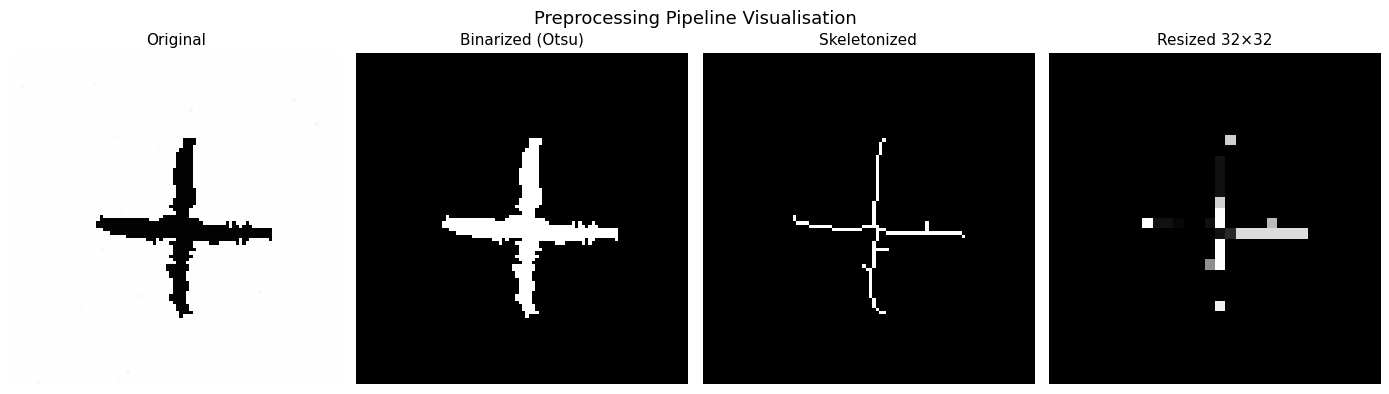

Stage 3 Complete ✅


In [18]:
# Visualise preprocessing stages for 1 sample image
sample_folder = list(class_mapping.keys())[0]
sample_path = os.path.join(dataset_path, sample_folder)
sample_file = os.path.join(sample_path,
                            os.listdir(sample_path)[0])

img_orig = cv2.imread(sample_file)
gray = cv2.cvtColor(img_orig, cv2.COLOR_BGR2GRAY)
_, binary = cv2.threshold(gray, 0, 255,
                           cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
skeleton = img_as_ubyte(skeletonize(binary > 0))
resized  = cv2.resize(skeleton, (32, 32))

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
titles = ['Original', 'Binarized (Otsu)', 'Skeletonized', 'Resized 32×32']
images = [cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB), binary, skeleton, resized]
cmaps  = [None, 'gray', 'gray', 'gray']

for ax, title, image, cmap in zip(axes, titles, images, cmaps):
    ax.imshow(image, cmap=cmap)
    ax.set_title(title, fontsize=11)
    ax.axis('off')

plt.suptitle('Preprocessing Pipeline Visualisation', fontsize=13)
plt.tight_layout()
plt.savefig('preprocessing_stages.png', dpi=150)
plt.show()
print("Stage 3 Complete ✅")